## Begin

### Import Statements

In [ ]:
import pandas as pd
import itertools
import json
import numpy as np
import re

### Load DataFrame

#### Constants

In [ ]:
algorithms = ['MDS', 'RANDOM', 'TSNE', 'UMAP', 'LLE', 'PCA', 'Isomap']

#### Function to Load

In [ ]:
def ret_df(filepath: str):
    # Read the JSON file
    with open(filepath, 'r') as f:
        data = json.load(f)

    # Create a list to store the data
    rows = []
    for dataset_key, values in data.items():
        # Split dataset name and number
        if 'fashion_mnist' in dataset_key:
            dataset_key = dataset_key.replace('fashion_mnist', 'fashion MNIST')

        dataset, run = dataset_key.split('_')
        
        # For each metric in the values
        for metric_key, value in values.items():
            # Split algorithm and metric type
            algorithm, metric = metric_key.split('_')
            
            # Add to rows
            rows.append({
                'Dataset': dataset,
                'Run': int(run),
                'Algorithm': algorithm,
                'Metric': metric,
                'Value': value
            })

    df = pd.DataFrame(rows)
    # Pivot the DataFrame to get the desired structure
    df = df.pivot_table(
        index=['Dataset', 'Run'],
        columns=['Metric', 'Algorithm'],
        values='Value'
    )

    # Only use algs in algorithms
    algs_to_drop = [alg for alg in df.columns.get_level_values(1).unique() if alg not in algorithms]
    df = df.drop(columns=algs_to_drop, level=1)

    # Rename the metric level of the columns
    metric_mapping = {
        'raw': 'RS',
        'norm': 'NS', 
        'sheppard': 'SGS',
        'scalenorm': 'SNS',
        'fsnorm': 'FSNS',
        'kruskal': 'NMS',
    }
    df.columns = pd.MultiIndex.from_tuples(
        [(metric_mapping[m], a) for m, a in df.columns],
        names=['Metric', 'Algorithm']
    )

    df = df[['RS', 'NS', 'SGS', 'NMS', 'SNS', 'FSNS']]
    
    # Normalize SGS to between 0 and 1, lower is better
    df.loc[:, ('SGS', algorithms)] = (1 - df.loc[:, ('SGS', algorithms)]) / 2

    return df

#### Create DataFrames for out1x and out10x

In [ ]:
stress_1x_df = ret_df('out1x.json')
stress_10x_df = ret_df('out10x.json')

### When is MDS much better than t-SNE according to SNS, and when are they equally performant?

In [ ]:
# When is SNS score for MDS 2.5 smaller than that for t-SNE?
sns_scores = stress_1x_df['SNS']
sns_scores[sns_scores['MDS'] * 2.5 < sns_scores['TSNE']]

Algorithm        Isomap       LLE       MDS       PCA    RANDOM      TSNE  \
Dataset   Run                                                               
epileptic 0    0.561691  0.826239  0.194593  0.520798  0.738327  0.657504   
          1    0.561691  0.826239  0.194892  0.520798  0.736746  0.661159   
          2    0.561691  0.826239  0.194921  0.520798  0.736274  0.651063   
          3    0.561691  0.826239  0.195061  0.520798  0.738898  0.652780   
          4    0.561691  0.826239  0.194795  0.520798  0.739373  0.658785   
          5    0.561691  0.826239  0.194780  0.520798  0.737363  0.664602   
          6    0.561691  0.826239  0.194745  0.520798  0.736326  0.653366   
          7    0.561691  0.826239  0.194810  0.520798  0.734797  0.657104   
          8    0.561691  0.826239  0.194954  0.520798  0.733580  0.658082   
          9    0.561691  0.826239  0.194653  0.520798  0.739568  0.654321   
iris      0    0.187234  0.713496  0.102116  0.093300  0.648855  0.264787   
          1    0.187234  0.713496  0.103248  0.093300  0.643687  0.262864   
          2    0.187234  0.713496  0.100558  0.093300  0.661200  0.307777   
          4    0.187234  0.713496  0.102310  0.093300  0.646164  0.264042   
          7    0.187234  0.713496  0.103247  0.093300  0.643952  0.258821   
          8    0.187234  0.713496  0.101901  0.093300  0.649817  0.266792   
          9    0.187234  0.713496  0.102029  0.093300  0.648056  0.259102   

Algorithm          UMAP  
Dataset   Run            
epileptic 0    0.701782  
          1    0.702864  
          2    0.703214  
          3    0.700590  
          4    0.732803  
          5    0.706816  
          6    0.726937  
          7    0.703345  
          8    0.703391  
          9    0.702940  
iris      0    0.318427  
          1    0.299255  
          2    0.257317  
          4    0.366258  
          7    0.400906  
          8    0.261983  
          9    0.391904

In [ ]:
# When is the SNS score for t-SNE not more than 20% larger that that of MDS
sns_scores[sns_scores['MDS'] * 1.2 > sns_scores['TSNE']]

Algorithm         Isomap       LLE       MDS       PCA    RANDOM      TSNE  \
Dataset    Run                                                               
bank       2    0.397697  0.707030  0.357785  0.393029  0.445413  0.426777   
fmd        2    0.378266  0.594812  0.334240  0.426433  0.457666  0.392380   
           8    0.378266  0.594812  0.334057  0.426434  0.457202  0.400084   
hatespeech 0    0.512865  0.879213  0.393640  0.609186  0.446406  0.424863   
           1    0.512865  0.878601  0.393383  0.609186  0.446450  0.426196   
...                  ...       ...       ...       ...       ...       ...   
wine       5    0.601836  0.607067  0.577499  0.560885  0.698624  0.588550   
           6    0.601836  0.607067  0.578756  0.560885  0.691417  0.592158   
           7    0.601836  0.607067  0.585366  0.560885  0.708161  0.596077   
           8    0.601836  0.607067  0.580427  0.560885  0.694792  0.593919   
           9    0.601836  0.607067  0.585972  0.560885  0.697933  0.595664   

Algorithm           UMAP  
Dataset    Run            
bank       2    0.414346  
fmd        2    0.442964  
           8    0.440894  
hatespeech 0    0.632879  
           1    0.635665  
...                  ...  
wine       5    0.609075  
           6    0.576692  
           7    0.576122  
           8    0.604635  
           9    0.589341  

[71 rows x 7 columns]

In [ ]:
pct_score_diff = ((sns_scores['TSNE'] - sns_scores['MDS'])/sns_scores['MDS']) * 100
print(f"Min : {pct_score_diff.min():.2f}")
print(f"Max : {pct_score_diff.max():.2f}")
print(f"Mean : {pct_score_diff.mean():.2f}")
print(f"Standard deviation : {pct_score_diff.std():.2f}")
print(f"Median : {pct_score_diff.median():.2f}")

Min : -0.49
Max : 241.21
Mean : 48.40
Standard deviation : 53.42
Median : 26.48


## Statistics

### Percent Orders

In [ ]:
def get_pct_order_df(df, algs):
    if isinstance(algs, str):
        algs = [algs]
    permutations = itertools.permutations(['MDS'] + algs)

    results = {}

    for perm in permutations:
        condition = pd.DataFrame(True, index=df.index, columns=df.columns.get_level_values(0).unique())
        for i in range(1, len(perm)):
            condition &= df.xs(perm[i-1], axis=1, level=1) <= df.xs(perm[i], axis=1, level=1)

        percentage = (condition).mean() * 100
        # results[" < ".join(perm)] = f"{percentage:.3}%"
        results[" < ".join(perm)] = percentage

    pct_order_df = pd.DataFrame(results).T
    # Round the following styler to 2nd decimal place
    return pct_order_df.style.background_gradient('Blues', vmin=0, vmax=150).format(lambda x : f"{x:.1f}%")

### Correlation

In [ ]:
score_corr_df = stress_1x_df.stack('Algorithm', future_stack=True).corr('spearman')

In [ ]:
def corr_styler(df: pd.DataFrame):
    df = df.round(2)
    mask = np.tril(np.ones(df.shape), k=-1).astype(bool)
    upper_triangled = df.mask(mask, -2)
    return upper_triangled.style.background_gradient('Blues', vmin=0, vmax=2).format(lambda x : '-' if x == -2 else x)

### Two comparisons only

In [ ]:
for alg in algorithms[1:]:
    pct_1x = get_pct_order_df(stress_1x_df, alg).set_caption(alg + " for 1x")
    display(pct_1x)
    pct_10x = get_pct_order_df(stress_10x_df, alg).set_caption(alg + " for 10x")
    display(pct_10x)
    
    print("\n\n")
    
score_corr_df = stress_1x_df.stack('Algorithm', future_stack=True).corr('spearman')
corr_styled = corr_styler(score_corr_df).set_caption("Correlation considering all algs and embeddings")
display(corr_styled)

Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < RANDOM,100.0%,100.0%,100.0%,100.0%,100.0%,95.4%
RANDOM < MDS,0.0%,0.0%,0.0%,0.0%,0.0%,4.6%


Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < RANDOM,20.4%,20.4%,100.0%,100.0%,100.0%,95.4%
RANDOM < MDS,79.6%,79.6%,0.0%,0.0%,0.0%,4.6%


Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < TSNE,87.5%,87.5%,93.3%,100.0%,99.6%,87.9%
TSNE < MDS,12.5%,12.5%,6.7%,0.0%,0.4%,12.1%


Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < TSNE,87.5%,87.5%,93.3%,100.0%,99.6%,87.9%
TSNE < MDS,12.5%,12.5%,6.7%,0.0%,0.4%,12.1%


Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < UMAP,83.3%,83.3%,94.6%,100.0%,98.8%,100.0%
UMAP < MDS,16.7%,16.7%,5.4%,0.0%,1.2%,0.0%


...

Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < PCA,95.8%,95.8%,79.6%,83.3%,85.8%,79.2%
PCA < MDS,4.2%,4.2%,20.4%,16.7%,14.2%,20.8%


Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < PCA,16.7%,16.7%,79.6%,83.3%,85.8%,79.2%
PCA < MDS,83.3%,83.3%,20.4%,16.7%,14.2%,20.8%


Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < Isomap,75.0%,75.0%,87.5%,100.0%,95.8%,93.3%
Isomap < MDS,25.0%,25.0%,12.5%,0.0%,4.2%,6.7%


Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < Isomap,62.5%,62.5%,87.5%,100.0%,95.8%,93.3%
Isomap < MDS,37.5%,37.5%,12.5%,0.0%,4.2%,6.7%


Metric,RS,NS,SGS,NMS,SNS,FSNS
Metric,,,,,,
RS,1.0,0.62,0.11,0.1,0.15,0.24
NS,-,1.0,0.22,0.28,0.34,0.3
SGS,-,-,1.0,0.76,0.77,0.66
NMS,-,-,-,1.0,0.93,0.81
SNS,-,-,-,-,1.0,0.9
FSNS,-,-,-,-,-,1.0


#### Triplets

In [ ]:
algs = ['TSNE', 'RANDOM']

x1_pct = get_pct_order_df(stress_1x_df, algs)
x1_pct.set_caption("Scale = 1")

x10_pct = get_pct_order_df(stress_10x_df, algs)
x10_pct.set_caption("Scale = 10")

corr_stress = corr_styler(stress_1x_df.stack('Algorithm', future_stack=True).corr('spearman'))
corr_stress.set_caption("Spearman correlation between stress scores")

display(x1_pct)
display(x10_pct)
display(corr_stress)

Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < TSNE < RANDOM,4.2%,4.2%,93.3%,82.1%,90.4%,66.7%
MDS < RANDOM < TSNE,83.3%,83.3%,0.0%,17.9%,9.2%,20.0%
TSNE < MDS < RANDOM,12.5%,12.5%,6.7%,0.0%,0.4%,8.8%
TSNE < RANDOM < MDS,0.0%,0.0%,0.0%,0.0%,0.0%,3.3%
RANDOM < MDS < TSNE,0.0%,0.0%,0.0%,0.0%,0.0%,1.2%
RANDOM < TSNE < MDS,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


Metric,RS,NS,SGS,NMS,SNS,FSNS
MDS < TSNE < RANDOM,0.0%,0.0%,93.3%,82.1%,90.4%,66.7%
MDS < RANDOM < TSNE,7.9%,7.9%,0.0%,17.9%,9.2%,20.0%
TSNE < MDS < RANDOM,12.5%,12.5%,6.7%,0.0%,0.4%,8.8%
TSNE < RANDOM < MDS,0.0%,0.0%,0.0%,0.0%,0.0%,3.3%
RANDOM < MDS < TSNE,79.6%,79.6%,0.0%,0.0%,0.0%,1.2%
RANDOM < TSNE < MDS,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


Metric,RS,NS,SGS,NMS,SNS,FSNS
Metric,,,,,,
RS,1.0,0.62,0.11,0.1,0.15,0.24
NS,-,1.0,0.22,0.28,0.34,0.3
SGS,-,-,1.0,0.76,0.77,0.66
NMS,-,-,-,1.0,0.93,0.81
SNS,-,-,-,-,1.0,0.9
FSNS,-,-,-,-,-,1.0


## Analysis of Percent Orders

In [ ]:
sns_score_df = stress_1x_df['SNS']
bad_runs = sns_score_df.index[~((sns_score_df['MDS'] < sns_score_df['LLE']) & (sns_score_df['LLE'] < sns_score_df['RANDOM']))]
bad_runs

MultiIndex([(    'bank', 0),
            (    'bank', 1),
            (    'bank', 2),
            (    'bank', 3),
            (    'bank', 4),
            (    'bank', 5),
            (    'bank', 6),
            (    'bank', 7),
            (    'bank', 8),
            (    'bank', 9),
            ...
            ('spambase', 0),
            ('spambase', 1),
            ('spambase', 2),
            ('spambase', 3),
            ('spambase', 4),
            ('spambase', 5),
            ('spambase', 6),
            ('spambase', 7),
            ('spambase', 8),
            ('spambase', 9)],
           names=['Dataset', 'Run'], length=190)

In [ ]:
sns_score_df.index[(sns_score_df[algorithms[1]] > sns_score_df['RANDOM'] * 1.5)]

MultiIndex([(      'bank', 0),
            (      'bank', 1),
            (      'bank', 2),
            (      'bank', 3),
            (      'bank', 4),
            (      'bank', 5),
            (      'bank', 6),
            (      'bank', 7),
            (      'bank', 8),
            (      'bank', 9),
            (     'cnae9', 0),
            (     'cnae9', 1),
            (     'cnae9', 2),
            (     'cnae9', 3),
            (     'cnae9', 4),
            (     'cnae9', 5),
            (     'cnae9', 6),
            (     'cnae9', 7),
            (     'cnae9', 8),
            (     'cnae9', 9),
            (    'coil20', 0),
            (    'coil20', 1),
            (    'coil20', 2),
            (    'coil20', 3),
            (    'coil20', 4),
            (    'coil20', 5),
            (    'coil20', 6),
            (    'coil20', 7),
            (    'coil20', 8),
            (    'coil20', 9),
            ('hatespeech', 0),
            ('hatespeech', 1),
        

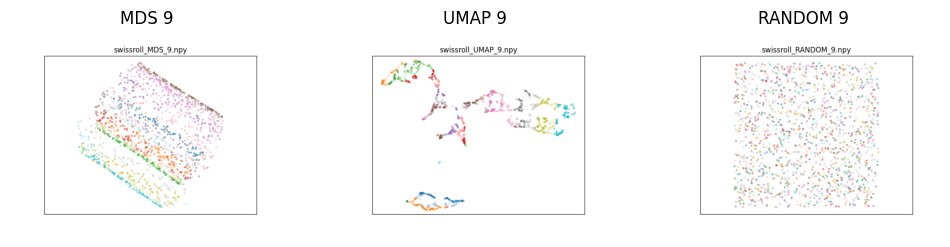

In [ ]:
import matplotlib.pyplot as plt
dataset = 'swissroll'
run = 9
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, alg in zip(axes, algorithms):
    fig_file = f"embedding_figs/{dataset}_{alg}_{run}.png"
    img = plt.imread(fig_file)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{alg} {run}")

In [ ]:
sns_score_df.loc['s-curve']

Algorithm,MDS,RANDOM,UMAP
Run,,,
0,0.235696,0.568234,0.336500
1,0.235672,0.565032,0.386194
2,0.235645,0.567731,0.366853
3,0.235583,0.565006,0.297656
4,0.235290,0.565634,0.354474
5,0.235136,0.567469,0.487846
6,0.235659,0.568545,0.433497
7,0.235516,0.566764,0.450654
8,0.233873,0.565515,0.512617


In [ ]:
import matplotlib.pyplot as plt
import os
fig, axes = plt.subplots(nrows=len(bad_runs), ncols=3, figsize=(5 * 3, 5 * len(bad_runs)))
for ax_row, (dataset, run) in zip(axes, bad_runs):
    for alg, ax in zip(algorithms, ax_row):
        fig_file = f"embedding_figs/{dataset}_{alg}_{run}.png"
        if os.path.exists(fig_file):
            img = plt.imread(fig_file)
            ax.imshow(img)
            ax.axis('off')
    break
plt.tight_layout()
plt.show()  

## Latex

In [ ]:
def get_latex_code(styler: pd.io.formats.style.Styler, entry_type='corr'):
    """
    Parameters
    ----------
    styler : 
    entry_type : 'corr' or 'pct'
    """
    corr_df = styler.data
    entries = corr_df.to_numpy()
    index = corr_df.index.tolist()
    cols = corr_df.columns.tolist()

    corr_css = styler.to_html()
    # print(corr_css)
    n_cols = len(styler.columns)
    n_rows = len(styler.index)
    colors = [["F"*6] * n_cols for _ in range(n_rows)]

    
    matches = re.findall(r'#T_\w+_row(\d+)_col(\d+)[^}]+background-color: #(\w+);', corr_css)

    # Fill the grid with the extracted background colors
    for match in matches:
        # print(match)
        row, col, color = int(match[0]), int(match[1]), match[2]
        colors[row][col] = color.upper()
    colors = np.array(colors)

    latex_code = f"""\\begin{{table}}[ht]
\\centering
\\caption{{}}
\\begin{{tabularx}}{{\\linewidth}}{{|p{{2cm}}| {'X ' * n_cols} |}}
\hline
"""

    for col in cols:
        latex_code += f"& \\small{{{col}}} "
    latex_code += "\\\\ \\hline \n"

    if entry_type == 'pct':
        index = [idx.replace(" < ", "$<$").replace("TSNE", "t-SNE").replace("RANDOM", "RND") for idx in index]

    for i in range(n_rows):
        latex_code += index[i]
        for color, entry in zip(colors[i], entries[i]):
            if entry_type == 'corr':
                tab_entry = entry if entry != -2 else '--'
            elif entry_type == 'pct':
                tab_entry = f'{float(entry):.1f}\\%'
            else:
                raise ValueError(f"entry_type should be either 'corr' or 'pct'. Got {entry_type} instead")
            latex_code += f" & \\cellcolor[HTML]{{{color}}} {tab_entry} "
        latex_code += "\\\\ \\hline \n"
    
    latex_code += """\\end{tabularx}
\\newline
\\label{tab:}
\\end{table}"""

    print(latex_code)
    return colors


In [ ]:

get_latex_code(corr_styler(score_corr_df), entry_type='corr')

\begin{table}[ht]
\centering
\caption{}
\begin{tabularx}{\linewidth}{|p{2cm}| X X X X X  |}
\hline
& \small{RS} & \small{NS} & \small{SGS} & \small{NMS} & \small{SNS} \\ \hline 
RS & \cellcolor[HTML]{6AAED6} 1.0  & \cellcolor[HTML]{99C7E0} 0.78  & \cellcolor[HTML]{EEF5FC} 0.09  & \cellcolor[HTML]{E3EEF8} 0.21  & \cellcolor[HTML]{D9E8F5} 0.3 \\ \hline 
NS & \cellcolor[HTML]{F7FBFF} --  & \cellcolor[HTML]{FFFFFF} 1.0  & \cellcolor[HTML]{E7F1FA} 0.16  & \cellcolor[HTML]{DDEAF7} 0.26  & \cellcolor[HTML]{D8E7F5} 0.32 \\ \hline 
SGS & \cellcolor[HTML]{FFFFFF} --  & \cellcolor[HTML]{FFFFFF} --  & \cellcolor[HTML]{FFFFFF} 1.0  & \cellcolor[HTML]{82BBDB} 0.89  & \cellcolor[HTML]{8ABFDD} 0.85 \\ \hline 
NMS & \cellcolor[HTML]{FFFFFF} --  & \cellcolor[HTML]{FFFFFF} --  & \cellcolor[HTML]{FFFFFF} --  & \cellcolor[HTML]{FFFFFF} 1.0  & \cellcolor[HTML]{84BCDB} 0.88 \\ \hline 
SNS & \cellcolor[HTML]{FFFFFF} --  & \cellcolor[HTML]{FFFFFF} --  & \cellcolor[HTML]{FFFFFF} --  & \cellcolor[HTML]{FFFFFF} -

array([['6AAED6', '99C7E0', 'EEF5FC', 'E3EEF8', 'D9E8F5'],
       ['F7FBFF', 'FFFFFF', 'E7F1FA', 'DDEAF7', 'D8E7F5'],
       ['FFFFFF', 'FFFFFF', 'FFFFFF', '82BBDB', '8ABFDD'],
       ['FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF', '84BCDB'],
       ['FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF']], dtype='<U6')

In [ ]:
get_latex_code(get_pct_order_df(stress_1x_df), entry_type='pct')

\begin{table}[ht]
\centering
\caption{}
\begin{tabularx}{\linewidth}{|p{2cm}| X X X X X  |}
\hline
& \small{RS} & \small{NS} & \small{SGS} & \small{NMS} & \small{SNS} \\ \hline 
MDS$<$t-SNE$<$RND & \cellcolor[HTML]{F2F7FD} 4.2\%  & \cellcolor[HTML]{FFFFFF} 4.2\%  & \cellcolor[HTML]{4292C6} 93.3\%  & \cellcolor[HTML]{5CA4D0} 81.7\%  & \cellcolor[HTML]{4A98C9} 90.0\% \\ \hline 
MDS$<$RND$<$t-SNE & \cellcolor[HTML]{58A1CF} 83.3\%  & \cellcolor[HTML]{FFFFFF} 83.3\%  & \cellcolor[HTML]{F7FBFF} 0.0\%  & \cellcolor[HTML]{DFEBF7} 18.3\%  & \cellcolor[HTML]{ECF4FB} 8.3\% \\ \hline 
t-SNE$<$MDS$<$RND & \cellcolor[HTML]{E7F0FA} 12.5\%  & \cellcolor[HTML]{FFFFFF} 12.5\%  & \cellcolor[HTML]{EEF5FC} 6.7\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{F5FAFE} 1.7\% \\ \hline 
t-SNE$<$RND$<$MDS & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\% \\ \hline 
RND$<$MDS$<$t-SNE & \c

array([['F2F7FD', 'FFFFFF', '4292C6', '5CA4D0', '4A98C9'],
       ['58A1CF', 'FFFFFF', 'F7FBFF', 'DFEBF7', 'ECF4FB'],
       ['E7F0FA', 'FFFFFF', 'EEF5FC', 'FFFFFF', 'F5FAFE'],
       ['FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF'],
       ['FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF'],
       ['FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF']], dtype='<U6')

In [ ]:
get_latex_code(get_pct_order_df(stress_10x_df), entry_type='pct')

\begin{table}[ht]
\centering
\caption{}
\begin{tabularx}{\linewidth}{|p{2cm}| X X X X X  |}
\hline
& \small{RS} & \small{NS} & \small{SGS} & \small{NMS} & \small{SNS} \\ \hline 
MDS$<$t-SNE$<$RND & \cellcolor[HTML]{F7FBFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{4292C6} 93.3\%  & \cellcolor[HTML]{5CA4D0} 81.7\%  & \cellcolor[HTML]{4A98C9} 90.0\% \\ \hline 
MDS$<$RND$<$t-SNE & \cellcolor[HTML]{EEF5FC} 7.5\%  & \cellcolor[HTML]{FFFFFF} 7.5\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{DFEBF7} 18.3\%  & \cellcolor[HTML]{ECF4FB} 8.3\% \\ \hline 
t-SNE$<$MDS$<$RND & \cellcolor[HTML]{E7F0FA} 12.5\%  & \cellcolor[HTML]{FFFFFF} 12.5\%  & \cellcolor[HTML]{FFFFFF} 6.7\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{F5FAFE} 1.7\% \\ \hline 
t-SNE$<$RND$<$MDS & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\%  & \cellcolor[HTML]{FFFFFF} 0.0\% \\ \hline 
RND$<$MDS$<$t-SNE & \cel

array([['F7FBFF', 'FFFFFF', '4292C6', '5CA4D0', '4A98C9'],
       ['EEF5FC', 'FFFFFF', 'FFFFFF', 'DFEBF7', 'ECF4FB'],
       ['E7F0FA', 'FFFFFF', 'FFFFFF', 'FFFFFF', 'F5FAFE'],
       ['FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF'],
       ['60A7D2', 'FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF'],
       ['FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF', 'FFFFFF']], dtype='<U6')

## Q3 NS vs. SNS comparison

### Load data

In [ ]:
# Download projections used in Espadoto Paper
import os
import subprocess

url = "https://mespadoto.github.io/proj-quant-eval/data/projections/projections.tar.gz"
tar_file = "projections.tar.gz"
extract_dir = "projections"

# Create directory if it doesn't exist
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)

    subprocess.run(["wget", url], check=True) # Download tar file
    subprocess.run(["tar", "-xzf", tar_file, "-C", extract_dir], check=True) # Extract contents
    os.remove(tar_file) # Delete tar file

[0] Downloading 'https://mespadoto.github.io/proj-quant-eval/data/projections/projections.tar.gz' ...
Saving 'projections.tar.gz'
HTTP response 200  [https://mespadoto.github.io/proj-quant-eval/data/projections/projections.tar.gz]


In [ ]:
!wget https://mespadoto.github.io/proj-quant-eval/data/projections/projections.tar.gz && mkdir -p projections && tar -xzf projections.tar.gz -C projections && rm projections.tar.gz



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://mespadoto.github.io/pr]87[Files: 0  Bytes: 0  [0 B/s] Re]87Saving 'projections.tar.gz'
87projections.tar.gz    15% [===>                          ]    4.42M    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87[Files: 0  Bytes: 0  [0 B/s] Re]87projections.tar.gz    35% [=========>                    ]    9.78M    5.35MB/s87projections.tar.gz    52% [==============>               ]   14.71M    5.14MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87[Files: 0  Bytes: 0  [0 B/s] Re]87projections.tar.gz    73% [=====================>        ]   20.58M    5.38MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87projections.tar.gz    93% [==========================>   ]   25.98M    5.38MB/s87projections.tar.gz   100% [=============================>]   27.84M    5.38MB/s87HTTP response 200  [https://mespadoto.github.io/proj-quant-eval/data/projections/projections.tar.gz]
87projections.tar.gz   100% [=============================>]   27.84M    5.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from metrics import Metrics
import tqdm
import os
import json

In [ ]:
small_data = {"auto-mpg.npy", "iris.npy", "penguins.npy", "s-curve.npy", "swissroll.npy", "wine.npy"}
# ORL removed because error in Espadoto repo
# Spambase removed because embeddings are missing in Espadoto repo
error_data = {"spambase.npy", "orl.npy"}

results = dict()
results_scale = dict()
datasets = [dataFname for dataFname in os.listdir('datasets') if dataFname not in small_data | error_data]


for dataFname in tqdm.tqdm(datasets):
    X = np.load(f'datasets/{dataFname}')
    dataname = dataFname.split(".")[0]
    results[dataname] = dict()
    results_scale[dataname] = dict()
    for alg in ["T-SNE", "MDS", "UMAP", "LLE", "ISO"]:

        Y = np.loadtxt(f'projections/proj_X_{dataname}_{alg}.csv', delimiter=',')

        M = Metrics(X,Y, setbatch=False)
        results[dataname][alg] = M.compute_normalized_stress()
        results_scale[dataname][alg] = M.compute_scale_normalized_stress()

100%|██████████| 16/16 [01:13<00:00,  4.56s/it]


In [ ]:
NS_ranking = pd.DataFrame.from_dict(results, orient='index')
NS_ranking = NS_ranking.rank(axis=1, method='min').astype(int)
SNS_ranking = pd.DataFrame.from_dict(results_scale, orient='index')
SNS_ranking = SNS_ranking.rank(axis=1, method='min').astype(int)

In [ ]:
df = pd.concat({"NS": NS_ranking, "SNS": SNS_ranking}, axis=1)
datasets = df.index.unique()
df.columns.names = ["Metric", "Algorithm"]
df

Metric           NS                    SNS                 
Algorithm     T-SNE MDS UMAP LLE ISO T-SNE MDS UMAP LLE ISO
bank              5   1    4   3   2     2   1    4   5   3
cifar10           5   1    3   4   2     3   1    4   5   2
cnae9             5   1    4   3   2     2   1    3   5   4
coil20            5   1    3   2   4     2   1    3   4   5
fashion_mnist     5   1    2   3   4     3   1    4   5   2
fmd               3   1    5   4   2     2   1    4   5   3
har               5   1    3   2   4     2   1    4   5   3
hatespeech        5   1    4   2   3     2   1    5   4   3
hiva              5   1    2   4   3     2   1    3   5   4
imdb              2   1    5   4   3     2   1    3   4   5
secom             5   1    3   2   4     2   1    3   5   4
seismic           5   1    4   2   3     2   1    3   5   4
sentiment         5   1    4   2   3     2   1    3   5   4
sms               4   1    5   3   2     2   1    3   5   4
svhn              5   1    2   4   3     3   1    5   4   2
epileptic         4   1    5   3   2     3   1    5   4   2

#### Statistics

In [ ]:
iso2nd = (df['NS', 'ISO'] == 2).mean()
print(f"ISO was 2nd in NS {iso2nd * 100:.2f}% of the time")
lle2nd = (df['NS', 'LLE'] == 2).mean()
print(f"LLE was 2nd in NS {lle2nd * 100:.2f}% of the time")
tsne2nd = (df['SNS', 'T-SNE'] == 2).mean()
print(f"t-SNE was 2nd in SNS {tsne2nd * 100:.2f}% of the time")

ISO was 2nd in NS 37.50% of the time
LLE was 2nd in NS 37.50% of the time
t-SNE was 2nd in SNS 75.00% of the time


In [ ]:
tsne_last = (df['NS', 'T-SNE'] == 5).mean()
print(f"t-SNE was last in NS {tsne_last * 100:.2f}% of the time")
lle_last = (df['SNS', 'LLE'] == 5).mean()
print(f"LLE was last in SNS {lle_last * 100:.2f}% of the time")


t-SNE was last in NS 75.00% of the time
LLE was last in SNS 68.75% of the time


##### **SNS**

In [ ]:
df['SNS'].mean(axis=0)

Algorithm
T-SNE    2.2500
MDS      1.0000
UMAP     3.6875
LLE      4.6875
ISO      3.3750
dtype: float64

In [ ]:
# Number of times each algorithm got the given ranking under SNS
pd.concat({i: (df['SNS'] == i).sum() for i in range(1, 6)}, axis=1)
    

,1,2,3,4,5
Algorithm,,,,,
T-SNE,0,12,4,0,0
MDS,16,0,0,0,0
UMAP,0,0,8,5,3
LLE,0,0,0,5,11
ISO,0,4,4,6,2


##### **NS**

In [ ]:
df['NS'].mean(axis=0)

Algorithm
T-SNE    4.5625
MDS      1.0000
UMAP     3.6250
LLE      2.9375
ISO      2.8750
dtype: float64

In [ ]:
# Number of times each algorithm got the given ranking under NS
pd.concat({i: (df['NS'] == i).sum() for i in range(1, 6)}, axis=1)

,1,2,3,4,5
Algorithm,,,,,
T-SNE,0,1,1,2,12
MDS,16,0,0,0,0
UMAP,0,3,4,5,4
LLE,0,6,5,5,0
ISO,0,6,6,4,0


### Visualizations

In [ ]:
colors = {
    "MDS": 'darkred',
    "ISO": 'orange',
    "LLE": 'deeppink',
    "UMAP": 'purple',
    "T-SNE": 'darkblue'
}

In [ ]:
import matplotlib.colors as mcolors

algs = ['MDS', 'T-SNE', 'UMAP', 'ISO', 'LLE']

# Hack to make it darker
step = 3
cmap = plt.get_cmap('Oranges', len(algs) + step)
hex_colors = [mcolors.to_hex(cmap(i + step)) for i in range(len(algs))]

colors = dict(zip(algs, hex_colors))

In [ ]:
n_rows = 2
n_columns = 8
size = 10
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns * 2 * size, n_rows * 5 * size), 
                        #  sharex=True, sharey=True
)
for i, dataset in enumerate(datasets):
    ax = axes.flatten()[i]
    coords = np.column_stack((np.array([0] * 5 + [1] * 5), -df.loc[dataset].to_numpy()))

    for alg, (x,y) in zip(np.tile(df.columns.get_level_values(1).unique(), 2), coords):
        rect = plt.Rectangle((x, y), 1, 1, facecolor=colors[alg], edgecolor='black')
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, alg, color='white', ha='center', va='center', fontweight='bold', fontsize=150)

    ax.set_xlim(0, 2)
    ax.set_ylim(-5, 0)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['NS', 'SNS'], fontsize=120)
    ax.set_yticks(np.arange(-0.5, -5.5, -1))
    ax.set_yticklabels(np.arange(1, 6), fontsize=120)
    ax.set_title(dataset, fontweight='bold', fontsize=150)

    if (i % n_columns == 0): ax.set_ylabel('Position', fontsize=20 * size)
    if (i >= n_columns * (n_rows - 1)): ax.set_xlabel('Metric', fontsize=20 * size)
    
plt.tight_layout()

In [ ]:
fig.savefig('figs/Q3_for_stress(2x8)_Oranges.pdf', format='pdf')

### Statistics

In [ ]:
iso2nd = (df['NS', 'ISO'] == 2).mean()
print(f"ISO was 2nd in NS {iso2nd * 100:.2f}% of the time")
lle2nd = (df['NS', 'LLE'] == 2).mean()
print(f"LLE was 2nd in NS {lle2nd * 100:.2f}% of the time")
tsne2nd = (df['SNS', 'T-SNE'] == 2).mean()
print(f"t-SNE was 2nd in SNS {tsne2nd * 100:.2f}% of the time")

ISO was 2nd in NS 33.33% of the time
LLE was 2nd in NS 40.00% of the time
t-SNE was 2nd in SNS 80.00% of the time


In [ ]:
tsne_last = (df['NS', 'T-SNE'] == 5).mean()
print(f"t-SNE was last in NS {tsne_last * 100:.2f}% of the time")
lle_last = (df['SNS', 'LLE'] == 5).mean()
print(f"LLE was last in SNS {lle_last * 100:.2f}% of the time")


t-SNE was last in NS 80.00% of the time
LLE was last in SNS 73.33% of the time
